## CSCI E-89 Deep Learning
### Lecture 01 Introduction to AI, ML & DL
## A Simple Example
#### 09/04/2026


### Setup TensorFlow

In [1]:
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1789175490.601619   70530 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0-dev0+selfbuilt


In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Auxiliary libraries
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

#### Load a dataset

In [4]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

Images are of 28X28 pixels. Lables are integers: 0, 1, 2,..., 9

In [5]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [6]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

#### Inspect an image

4


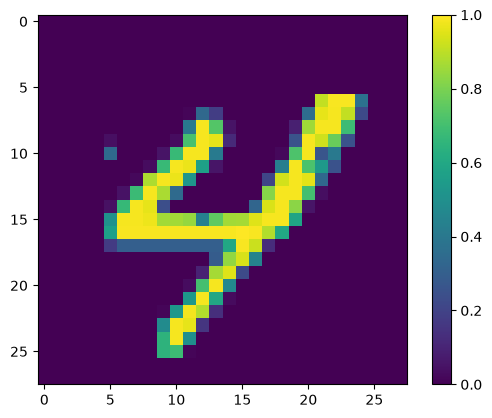

In [7]:
index = 89
print(y_train[index])
plt.figure()
plt.imshow(x_train[index])
plt.colorbar()
plt.grid(False)
plt.show()

#### Build a machine learning model

Sequential model is useful for stacking layers where each layer has one input tensor and one output tensor. Layers are functions with a known mathematical structure that can be reused and have trainable variables. Most TensorFlow models are composed of layers. This model uses the Flatten, Dense, and Dropout layers.

In [8]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

/home/zoe/Github/deep_learning_course/.venv-1/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1789175493.228937   70530 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15628 MB memory:  -> device: 0, name: AMD Radeon RX 6800 XT, pci bus id: 0000:03:00.0


For each example, the model returns a vector of logits or log-odds scores, one for each class.

In [9]:
predictions = model(x_train[:1]).numpy()
predictions

array([[-0.06513754,  0.28947213, -0.24014756, -0.15055816,  0.07430751,
        -0.2950971 ,  0.0828611 , -0.5425881 ,  0.15387796,  1.226714  ]],
      dtype=float32)

The `tf.nn.softmax`function converts these logits to probabilities for each class:

In [10]:
tf.nn.softmax(predictions).numpy()

array([[0.07817604, 0.11144964, 0.06562477, 0.07177545, 0.08987395,
        0.062116  , 0.090646  , 0.04849751, 0.09731748, 0.28452316]],
      dtype=float32)

Define a loss function for training using `losses.SparseCategoricalCrossentropy`:

In [11]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

The loss function takes a vector of ground truth values and a vector of logits and returns a scalar loss for each example. This loss is equal to the negative log probability of the true class: The loss is zero if the model is sure of the correct class.

This untrained model gives probabilities close to random (1/10 for each class), so the initial loss should be close to `-tf.math.log(1/10) ~= 2.3`.

In [12]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.7787519)

Before you start training, configure and compile the model using Keras `Model.compile`. Set the optimizer class to `adam`, set the `loss` to the `loss_fn` function you defined earlier, and specify a `metric` to be evaluated for the `model` by setting the `etrics` parameter to `accuracy`.

In [13]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

#### Train and evaluate your model
Use the `Model.fit` method to adjust your `model` parameters and minimize the `loss`:

In [14]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


I0000 00:00:1789175495.085757   70530 service.cc:153] XLA service 0x5e02c43e9cd0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789175495.085772   70530 service.cc:161]   StreamExecutor [0]: AMD Radeon RX 6800 XT, AMDGPU ISA version: gfx1030 (Driver: 7.14.60850; Runtime: 7.14.60850; Toolkit: 7.14.60850; DNN: 0.0.0)
I0000 00:00:1789175495.096749   70530 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789175495.192697   70530 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_879__XlaMustCompile_true_config_proto_2201667018877855759_executor_type_11160318154034397263_.11


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 57:48 2s/step - accuracy: 0.0000e+00 - loss: 2.4949

I0000 00:00:1789175496.509864   70530 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9142 - loss: 0.2965
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9581 - loss: 0.1418
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9685 - loss: 0.1038
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9735 - loss: 0.0853
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9783 - loss: 0.0713


The `Model.evaluate` method checks the model's performance, usually on a validation set or test set.

In [15]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.9771 - loss: 0.0775


[0.07751432806253433, 0.9771000146865845]

The image classifier is now trained to ~98% accuracy on this dataset. 